In [1]:
print('Installing the kaggle library...')
!pip install kaggle
print('Kaggle library installed.')

Installing the kaggle library...
Kaggle library installed.


In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_491344be42578a9ce9858ad6bd9ea050'
print('KAGGLE_API_TOKEN environment variable set.')

KAGGLE_API_TOKEN environment variable set.


In [4]:
import os

# Set KAGGLE_USERNAME and KAGGLE_KEY environment variables for authentication.
# The provided 'KAGGLE_API_TOKEN' (KGAT_...) is used as the KAGGLE_KEY.
# A placeholder username 'colab_user' is used as a specific username was not provided.
os.environ['KAGGLE_USERNAME'] = 'colab_user'
os.environ['KAGGLE_KEY'] = 'KGAT_491344be42578a9ce9858ad6bd9ea050'

print('KAGGLE_USERNAME and KAGGLE_KEY environment variables set for Kaggle API authentication.')

KAGGLE_USERNAME and KAGGLE_KEY environment variables set for Kaggle API authentication.


In [5]:
import kaggle
print("Kaggle library imported successfully.")

Kaggle library imported successfully.


In [7]:
import os

dataset_identifier = 'salader/dogsvscats'
download_path = 'kaggle_dataset'

# Create the directory if it doesn't exist
os.makedirs(download_path, exist_ok=True)
print(f"Directory '{download_path}' ensured.")

# Download and unzip the dataset
print(f"Downloading dataset '{dataset_identifier}' to '{download_path}'...")
kaggle.api.dataset_download_files(dataset_identifier, path=download_path, unzip=True)
print(f"Dataset '{dataset_identifier}' downloaded and unzipped to '{download_path}'.")

Directory 'kaggle_dataset' ensured.
Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
Dataset 'salader/dogsvscats' downloaded and unzipped to 'kaggle_dataset'.


In [8]:
import os

download_path = 'kaggle_dataset'

# List the contents of the download directory to find the dataset file(s)
print(f"Contents of the '{download_path}' directory:")
for item in os.listdir(download_path):
    print(f"- {item}")

Contents of the 'kaggle_dataset' directory:
- catsvsdogs
- test
- train


In [18]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout


In [10]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='kaggle_dataset/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)
test = keras.utils.image_dataset_from_directory(
    directory='kaggle_dataset/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [11]:
# normalize
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
test = test.map(process)


In [19]:
#creat cnn

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [22]:
history = model.fit(train_ds,epochs=10,validation_data=test)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.5720 - loss: 2.7321 - val_accuracy: 0.6582 - val_loss: 0.6186
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 93ms/step - accuracy: 0.7024 - loss: 0.5887 - val_accuracy: 0.6474 - val_loss: 0.6396
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.7582 - loss: 0.4994 - val_accuracy: 0.7708 - val_loss: 0.4909
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7946 - loss: 0.4397 - val_accuracy: 0.7602 - val_loss: 0.5181
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8326 - loss: 0.3800 - val_accuracy: 0.7524 - val_loss: 0.5387
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8686 - loss: 0.3074 - val_accuracy: 0.8042 - val_loss: 0.4357
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.8960 - loss: 0.2456 - val_accuracy: 0.8114 - val_loss: 0.4721
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.9311 - loss: 0.1756 - 

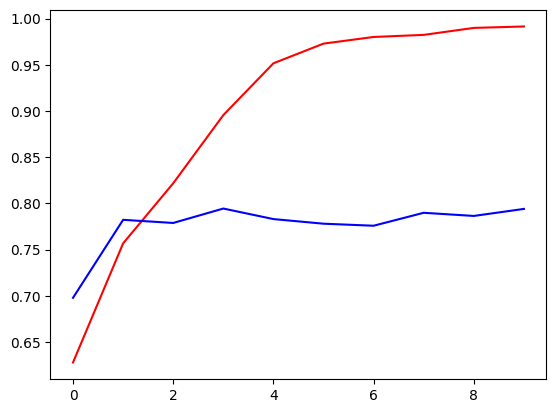

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')

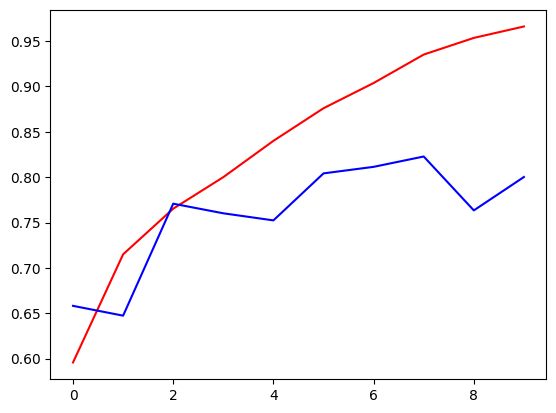

In [23]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')

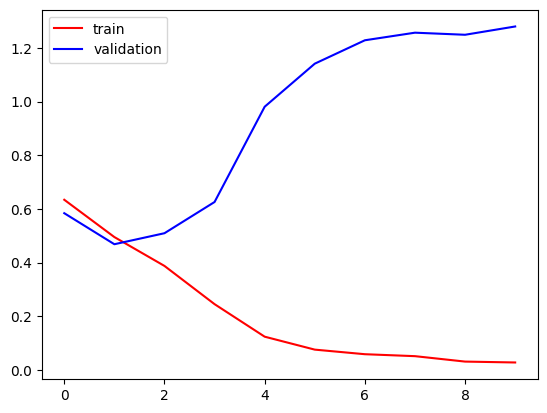

In [17]:
plt.plot(history.history['loss'],color = 'red',label = 'train')
plt.plot(history.history['val_loss'],color = 'blue',label = 'validation')
plt.legend()
plt.show()

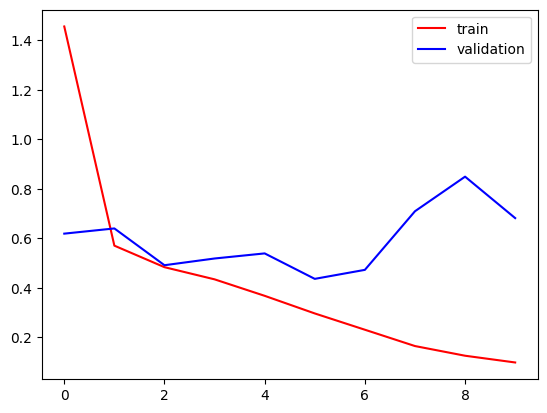

In [24]:
plt.plot(history.history['loss'],color = 'red',label = 'train')
plt.plot(history.history['val_loss'],color = 'blue',label = 'validation')
plt.legend()
plt.show()

In [25]:
import cv2

In [35]:
test_img = cv2.imread('kaggle_dataset/dog.jfif')

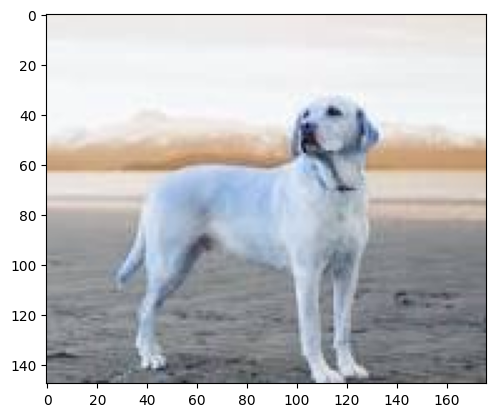

In [36]:
plt.imshow(test_img)

In [37]:
test_img.shape

(148, 176, 3)

In [38]:
test_img = cv2.resize(test_img,(256,256))

In [39]:
test_input = test_img.reshape((1,256,256,3))

In [40]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)